In [464]:
# Author: Niko Bleidistel
# last change: 2026-08-19

# Start

## Package Import

In [494]:
from pathlib import Path
from os import makedirs
import sys
import re

import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import importlib

In [495]:
PYTHON_HELPER_FOLDER = Path(r"py-helpers")

# Add the path to the custom packages to sys.path so that they can be imported
sys.path.append(str(PYTHON_HELPER_FOLDER.resolve()))

# import custom packages
import time_logging as tl
import comsol_data_import as cdi
import advanced_plotting_functions as apf

import comsol_data_plotting2 as cdp
import theory_fit_models as tfm

# reload custom packages (for each execution) to reflect recent changes
_ = importlib.reload(tl)
_ = importlib.reload(cdi)
_ = importlib.reload(apf)
_ = importlib.reload(cdp)
_ = importlib.reload(tfm)

In [496]:
# for type hinting

import matplotlib.axes
import matplotlib.figure

## PATHS

In [497]:
MAIN_FOLDER = Path(r"R:\Bleidistel_Niko\mid res")
INPUT_FOLDER = MAIN_FOLDER / "RESULTS"
OUTPUT_FOLDER = MAIN_FOLDER / "SPECIFIC PLOTS"

makedirs(OUTPUT_FOLDER, exist_ok=True)  # create output folder if it doesn't exist

In [498]:
# initialize time logging
_ = tl.initialize_time_log(OUTPUT_FOLDER / 'time_log.csv')

In [499]:
if False:
    input_folder = INPUT_FOLDER

    def mask(filename):
        return not (str(filename).endswith('.mph') or str(filename).endswith('.csv'))

    import seedir as sd
    sd.seedir(input_folder, style='lines', mask=mask)

In [500]:
if False:
    folders = [f for f in INPUT_FOLDER.rglob("*") if f.is_dir()]
    data_export_folders = [f for f in folders if "Data Export" in f.name]
    sweep_export_folders = [f for f in folders if "Sweep Export" in f.name]
    display(data_export_folders)
    display(sweep_export_folders)

In [501]:
FOLDER_01_00 = "01_00-Meshing and POC"
FOLDER_01_XX = "01_xx-Coils and Grid Designs"
FOLDER_02_00 = "02_00-H Designs"

FOLDER_01_01 = "01_01-Coils"
FOLDER_01_02 = "01_02-Grid"
FOLDER_01_03 = "01_03-Combined Coils and Grid"

In [502]:
MODELS_01_00 = [
    "01_00_a-auto mesh",
    "01_00_b-high resolution cuboid",
    "01_00_c-high resolution planes",
    "01_00_d-high resolution planes and increasing areas"
]
MODELS_01_01 = [
    "01_01_a-Round spiral",
    "01_01_b-Rectangular spiral",
]
MODELS_01_02 = [
    "01_02_a-Grid",
]
MODELS_01_03 = [
    "01_03_a-Round spiral combined with grid",
    "01_03_b-Rectangular spiral combined with grid",
]
MODELS_02_00 = [
    "02_00_a-H design with minimized insulator",
    "02_00_b-H design with full insulator",
]

In [503]:
DATA_EXPORT = "Data Export"

In [504]:
TERMINAL_END = "-terminals.csv"
PARAMETER_END = "-parameters.csv"
DEPTH_END = "-depth_exported_data.txt"
HOMOGENEITY_END = "-homogeneity_exported_data.txt"
LONGITUDINAL_END = "-longitudinal_exported_data.txt"
XY_PLANE_END = "-xy_exported_data.txt"
CONDUCTOR_PLANE_END = "-conductor_exported_data.txt"

In [505]:
SWEEP_01_XX = {
    "01_01_a-Round spiral": "Sweep - N_spiral_turns",
    "01_02_a-Grid": "Sweep - Voltage angles and left_out_lines",
    "01_03_a-Round spiral combined with grid": "Sweep - Voltage angles",
    "01_03_b-Rectangular spiral combined with grid": "Sweep - Voltage angles",
}
SWEEP_02_00 = {
    "02_00_a-H design with minimized insulator": "Sweep",
    "02_00_b-H design with full insulator": "Sweep",
}

In [506]:
SWEEP_FOLDER = "Sweep" # + " - " + kindOfSweep
LEFT_OUT_LINES = "left_out_lines" # + " - " + Number

SWEEP_EXPORT = "Sweep Export"

## TRANSLATION (Constants)

In [507]:
GROUPNAME_01_00 = "Different Meshing Approaches and Proof of Concept"
GROUPNAME_02_00 = r"\enquote{H}-Designs"

GROUPNAME_01_01 = "Coil Designs"
GROUPNAME_01_02 = "Grid Design"
GROUPNAME_01_03 = "Combined Grid and Coil Design"

In [508]:
# translate comsol label to nicer plot labels
TRANSLATE_PLOTLABELS = {
    "x":                r"$x$-axis $[\mathrm{m}]$",
    "y":                r"$y$-axis $[\mathrm{m}]$",
    "z":                r"$z$-axis $[\mathrm{m}]$",
    "mf.normB (T)":     "Magnetic flux density, norm\n\n"+r"$|\vec{B}|$ $[\mathrm{T}]$",
    "mf.Bx (T)":        "Magnetic flux density, x-component\n\n"+r"$B_x$ $[\mathrm{T}]$", 
    "mf.By (T)":        "Magnetic flux density, y-component\n\n"+r"$B_y$ $[\mathrm{T}]$", 
    "mf.Bz (T)":        "Magnetic flux density, z-component\n\n"+r"$B_z$ $[\mathrm{T}]$",
    "T (K)":            "Relative Temperature\n\n"+r"$T$ $[\mathrm{K}]$",
    "V (V)":            "Electric potential\n\n"+r"$V$ $[\mathrm{V}]$",
    "ec.normJ (A/m^2)": "Current density, norm\n\n"+r"$|\vec{J}|$ $[\mathrm{A}/\mathrm{m}^2]$",
    "ec.Jx (A/m^2)":    "Current density, x-component\n\n"+r"$J_x$ $[\mathrm{A}/\mathrm{m}^2]$",
    "ec.Jy (A/m^2)":    "Current density, y-component\n\n"+r"$J_y$ $[\mathrm{A}/\mathrm{m}^2]$",
    "ec.Jz (A/m^2)":    "Current density, z-component\n\n"+r"$J_z$ $[\mathrm{A}/\mathrm{m}^2]$",
    "Set angle (°)":    "Set angle\n\n"+r"$\theta$ $[\degree]$",
    "Angle Error (°)":  "Angle error\n\n"+r"$\Delta\theta$ $[\degree]$",
}

In [509]:
X_AXIS_PARAMS = ["x", "y", "z"]
Y_AXIS_PARAMS = [key for key in TRANSLATE_PLOTLABELS.keys() if key not in X_AXIS_PARAMS]

In [510]:
THEORY_PLOT_POINTS = 150

In [511]:
# translate theory plot labels to theory formula indices
THEORY_FORMULA = {
    "mf.Bx (T)":        0, 
    "mf.By (T)":        1, 
    "mf.Bz (T)":        2,
}

In [512]:
T_0 = 293.15 # [K]

# 01_00-Meshing and POC

## BASE

In [484]:
group_input_folder = INPUT_FOLDER / FOLDER_01_00
group_output_folder = OUTPUT_FOLDER / FOLDER_01_00

In [485]:
group_length = len(MODELS_01_00)

group_model = []
group_label = []
group_terminals = []
group_parameters = []
for midx in range(group_length):
    # get all modelnames
    group_model.append(MODELS_01_00[midx])
    group_label.append(MODELS_01_00[midx].split('-')[-1])

    # get all terminal dataframes
    terminals = group_input_folder/ MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{TERMINAL_END}"
    df_terminal = pd.read_csv(terminals)
    group_terminals.append(df_terminal)

    # get all parameter dataframes
    parameters = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{PARAMETER_END}"
    df_parameters = pd.read_csv(parameters).drop(labels = "description", axis = 1)
    group_parameters.append(df_parameters)

In [486]:
df_parameters = group_parameters[0]  # assuming constant parameters (besides meshing)

In [487]:
display(group_label)

['auto mesh',
 'high resolution cuboid',
 'high resolution planes',
 'high resolution planes and increasing areas']

In [488]:
y_axis_params = [
    "mf.Bx (T)",
    "mf.By (T)",
    "mf.Bz (T)",
    "T (K)",
]
y_axis_params_con_plane = [
    # "ec.Jx (A/m^2)",
    # "ec.Jy (A/m^2)",
    # "ec.Jz (A/m^2)",
    # "V (V)",
] 

In [489]:
def add_magnetic_theory(
        fig: matplotlib.figure.Figure,
        ax: matplotlib.axes.Axes,
        df_parameters: pd.DataFrame,
        xparam: str,
        Bidx: int,
        discretization_length:float = 3e-6,
        z_pos: float | None = None,
        )-> tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Add a theoretical magnetic field curve to the provided matplotlib axis based on the Biot-Savart law.
    
    Args:
        fig (matplotlib.figure.Figure):             The matplotlib figure object.
        ax (matplotlib.axes.Axes):                  The matplotlib axes object where the theory curve will be added.
        df_parameters (pd.DataFrame):               DataFrame containing the necessary parameters for the Biot-Savart law calculation.
        Bidx (int):                                 Index indicating which component of the magnetic field to plot (0 for Bx, 1 for By, 2 for Bz).
        discretization_length (float, optional):    Minimum discretization length for the x-limits. Defaults to 3e-6.
        z_pos (float | None, optional):             Optional z-position for the theory curve. If None, the z-position will be determined based on the xparam. Defaults to None.
        
    Returns:
        tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]: The updated figure and axes objects with the theory curve added.
    """
    if xparam not in ["x", "y", "z"]:
        print(f"Warning: xparam '{xparam}' not in ['x', 'y', 'z']. Skipping theory curve generation.")
        return fig, ax 

    # Get the x-coordinates of all scatter points and lines in the current axis
    all_x_data = []
    for collection in ax.collections:
        offsets = collection.get_offsets() # get the coordinates of the scatter points
        all_x_data.extend(offsets[:, 0]) # extend the list with the x-coordinates
    for line in ax.get_lines():
        all_x_data.extend(line.get_xdata()) # extend the list with the x-coordinates of the lines

    # Determine the x-limits based on the data
    if all_x_data:
        xlimits = [min(all_x_data), max(all_x_data)]
    else: 
        xlimits = list(ax.get_xlim()) # fallback to the current axis limits if no data is found

    # apply a minimum discretization length to the x-limits
    if xparam == "z":
        for i in range(2):
            if abs(xlimits[i]) < 0.5*discretization_length:
                xlimits[i] = np.sign(xlimits[i]) * 0.8*discretization_length

    # Check if the x-limits are equal, which would prevent generating a theory curve
    if xlimits[0] == xlimits[1]:
        raise ValueError("xlimits are equal, cannot generate theory curve.")
    
    # Generate x values for the theory curve
    x = np.linspace(xlimits[0], xlimits[1], THEORY_PLOT_POINTS)

    # extract the necessary parameters from the DataFrame for the Biot-Savart law calculation
    mask = df_parameters["name"] == "conductor_all_length"
    con_length = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "conductor_all_width"
    con_width = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    num_w = 2 * max(round(con_width / discretization_length), 1)

    mask = df_parameters["name"] == "conductor_all_height"
    con_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    num_h = 2 * max(round(con_height / discretization_length), 1)

    mask = df_parameters["name"] == "I_conductor_terminal"
    I_con = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    
    # get y values
    y = [np.nan] * len(x)
    for i, x_val in enumerate(x):
        # Determine the position
        z_pos = z_pos if z_pos is not None else 0.0
        pos = (0, 0, 0)
        if xparam == "x":
            pos = (x_val, 0, z_pos)
        if xparam == "y":
            pos = (0, x_val, z_pos)
        if xparam == "z":
            pos = (0, 0, x_val)

        # Calculate the magnetic field using the Biot-Savart law for a rectangular conductor
        B = tfm.biot_savart_rectangular_conductor(
            pos = pos,    
            R_con = [(0.5*con_length, 0, 0.5*con_height), (-0.5*con_length, 0, 0.5*con_height)],  
            I = I_con,
            width_vec = (0, con_width, 0),
            height_vec = (0, 0, con_height),
            num_w = num_w,
            num_h = num_h,           
        )     
        y[i]=B[Bidx]

    ax.plot(x, y, label=fr"Biot-Savart with ${num_w} \times {num_h}$ conductors", color="tab:red")#, s=apf.MARKERSIZE)

    # get y values
    y = [np.nan] * len(x)
    for i, x_val in enumerate(x):
        # Determine the position
        z_pos = z_pos if z_pos is not None else 0.0
        pos = (0, 0, 0)
        if xparam == "x":
            pos = (x_val, 0, z_pos)
        if xparam == "y":
            pos = (0, x_val, z_pos)
        if xparam == "z":
            pos = (0, 0, x_val)

        # Calculate the magnetic field using the Biot-Savart law for a rectangular conductor
        B = tfm.biot_savart_rectangular_conductor(
            pos = pos,    
            R_con = [(0.5*con_length, 0, 0), (-0.5*con_length, 0, 0)],  
            I = I_con,
            width_vec = (0, con_width, 0),
            height_vec = (0, 0, con_height),
            num_w = num_w,
            num_h = num_h,           
        )     
        y[i]=B[Bidx]

    ax.plot(x, y, label=fr"Biot-Savart with OFFSET ${num_w} \times {num_h}$ conductors", color="tab:blue")#, s=apf.MARKERSIZE)

    return fig, ax

In [490]:
df_conductivity = pd.DataFrame({
    "name": ["conductor", "insulator", "epilayer", "substrate"],    # layer names (order matters for the temperature calculation)
    "thermal_conductivity": [429, 1.38, 450, 450],               # thermal conductivity in W/(m·K)
    "electrical_conductivity": [61.6e6, np.nan, np.nan, np.nan],    # electrical conductivity in S/m
    })

def add_temperature_theory(
        fig: matplotlib.figure.Figure,
        ax: matplotlib.axes.Axes,
        df_parameters: pd.DataFrame,
        xparam: str,
        df_layer: pd.DataFrame = df_conductivity,
        z_pos: float = 0.0,
        ):
    """
    Add a theoretical temperature curve to the provided matplotlib axis.
    """
    
    if xparam not in ["x", "y", "z"]:
        print(f"Warning: xparam '{xparam}' not in ['x', 'y', 'z']. Skipping theory curve generation.")
        return fig, ax 

    # Get the x-coordinates of all scatter points and lines in the current axis
    all_x_data = []
    for collection in ax.collections:
        offsets = collection.get_offsets() # get the coordinates of the scatter points
        all_x_data.extend(offsets[:, 0]) # extend the list with the x-coordinates
    for line in ax.get_lines():
        all_x_data.extend(line.get_xdata()) # extend the list with the x-coordinates of the lines

    # Determine the x-limits based on the data
    if all_x_data:
        xlimits = [min(all_x_data), max(all_x_data)]
    else: 
        xlimits = list(ax.get_xlim()) # fallback to the current axis limits if no data is found

    # Check if the x-limits are equal, which would prevent generating a theory curve
    if xlimits[0] == xlimits[1]:
        raise ValueError("xlimits are equal, cannot generate theory curve.")
    
    # Generate x values for the theory curve
    x = np.linspace(xlimits[0], xlimits[1], THEORY_PLOT_POINTS)

    # extract the necessary parameters from the DataFrame
    width_mask = df_parameters["name"].str.contains("_width", na=False)
    height_mask = df_parameters["name"].str.contains("_height", na=False)

    for layer in df_layer["name"]:
        layer_mask = df_parameters["name"].str.contains(layer, na=False) & ~df_parameters["name"].str.contains("distortion", na=False)

        width_series = df_parameters.loc[layer_mask & width_mask, "evaluated_value"]
        if not width_series.empty:
            df_layer.loc[df_layer["name"] == layer, "width"] = width_series.iloc[0]
        else:
            raise ValueError(f"Width for layer '{layer}' not found in df_parameters.")

        height_series = df_parameters.loc[layer_mask & height_mask, "evaluated_value"]
        if not height_series.empty:
            df_layer.loc[df_layer["name"] == layer, "height"] = height_series.iloc[0]
        else:
            raise ValueError(f"Height for layer '{layer}' not found in df_parameters.")

    # get the current through the conductor layer
    mask = df_parameters["name"] == "I_conductor_terminal"
    I_con = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    # get power per length for the conductor layer
    power_per_length = tfm.power_per_length(
            I = I_con,
            sigma = df_layer[df_layer["name"] == "conductor"]["electrical_conductivity"].iloc[0],
            h = df_layer[df_layer["name"] == "conductor"]["height"].iloc[0],
            w = df_layer[df_layer["name"] == "conductor"]["width"].iloc[0],
        )

    # set start values for z and y positions and isothermal temperature
    T_iso = 293.15  # Isothermal temperature in Kelvin
    z_plot: float = z_pos 
    y_plot: float = 0.0

    if True:
        # get y values
        y = [np.nan] * len(x)
        for i, x_val in enumerate(x):
            if xparam == "z":
                    z_plot = x_val
                    y_plot = 0.0
            if xparam == "y":
                    z_plot = z_pos 
                    y_plot = x_val
            
            T = tfm.temp_est_line_source_approximation(
                    df = df_layer,
                    power_per_length = power_per_length,
                    z = z_plot,
                    y = y_plot,
                    T_iso = T_iso,
                )
            
            y[i] = T - T_iso # store the relative temperature (T - T_iso) in the y array
            
        # plot
        ax.plot(x, y, label="Theory: line source approximation", color="tab:blue")#, s=apf.MARKERSIZE)

    if False:
        # get y values
        y = [np.nan] * len(x)
        for i, x_val in enumerate(x):
            if xparam == "z":
                    z_plot = x_val
                    y_plot = 0.0
            if xparam == "y":
                    z_plot = z_pos 
                    y_plot = x_val
            
            T = tfm.temp_est_refraction_spreading(
                    df = df_layer,
                    power_per_length = power_per_length,
                    z = z_plot,
                    y = y_plot,
                    T_iso = T_iso,
                )
            
            y[i] = T - T_iso # store the relative temperature (T - T_iso) in the y array
            
        # plot
        ax.plot(x, y, label="Theory: extended source per layer,\n increased spreading per thermal refraction", color="tab:green")#, s=apf.MARKERSIZE)

    if True:
        # get y values
        y = [np.nan] * len(x)
        for i, x_val in enumerate(x):
            if xparam == "z":
                    z_plot = x_val
                    y_plot = 0.0
            if xparam == "y":
                    z_plot = z_pos 
                    y_plot = x_val
            
            T = tfm.temp_est_integration_spreading(
                    df = df_layer,
                    power_per_length = power_per_length,
                    z = z_plot,
                    y = y_plot,
                    T_iso = T_iso,
                )
            
            y[i] = T - T_iso # store the relative temperature (T - T_iso) in the y array
            
        # plot
        ax.plot(x, y, label="Theory: extended source,\n        spreading per integration from top", color="tab:red")#, s=apf.MARKERSIZE)


    return fig, ax

## z-axis (depth)

In [491]:
output_folder = group_output_folder / "z axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [492]:
group_depth = []
for midx in range(group_length):
    # get all depth dataframes
    depth = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{DEPTH_END}"
    depth_header_data, depth_df = cdi.read_comsol_export(str(depth))

    # drop the x and y columns, as they are not needed for depth plots
    depth_df.drop(labels=["x", "y"], axis=1, inplace=True)

    # adjust the temperature values to be relative to T_0
    depth_df["T (K)"] = depth_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in depth_df.columns else depth_df["T (K)"]
    group_depth.append(depth_df)

KeyboardInterrupt: 

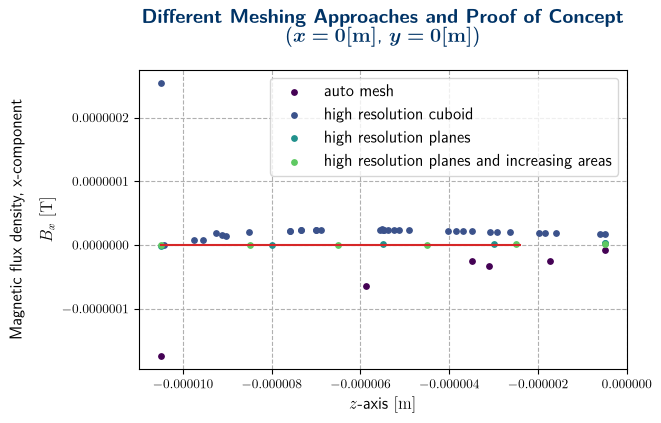

In [493]:
fraction = 1
xparam = "z"
for yparam in y_axis_params:
    if xparam not in group_depth[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_depth[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    # create figure and axis for plotting
    fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

        
    # Data
    cmap = mpl.colormaps['viridis'] # type: ignore
    
    for midx in range(group_length):
               
        df_plot = group_depth[midx][[xparam, yparam]].copy()
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = None,

                    label = group_label[midx],
                    color = cmap(midx / group_length),
                    translation_dict = TRANSLATE_PLOTLABELS,

                    fig = fig,
                    ax = ax,

                    title = GROUPNAME_01_00 + r" ($\bm{x = 0 [\mathrm{m}]}$, $\bm{y = 0 [\mathrm{m}]}$)",
                    x_label = xparam,
                    y_label = yparam,
                )

    # Theory
    if True and "mf.B" in yparam:
        idx = THEORY_FORMULA[yparam]
        fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6)

    if True and "T (K)" in yparam:
        fig, ax = add_temperature_theory(fig, ax, df_parameters, xparam=xparam, df_layer=df_conductivity)

    fig, ax = apf.plot_background(fig, ax)
    
    ax.legend(
        loc="upper center", 
        bbox_to_anchor=(0.5, -0.15/fraction), 
        ncol=2
        )
    clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
    apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}")

## y-axis (homogenity)

In [ ]:
output_folder = group_output_folder / "y axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_homogenity = []
unique_z_values = []
for midx in range(group_length):
    # get all homogenity dataframes
    homogenity = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{HOMOGENEITY_END}"
    homogenity_header_data, homogenity_df = cdi.read_comsol_export(str(homogenity))

    # drop the x column, as it is not needed for homogenity plots
    homogenity_df.drop(labels=["x"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    homogenity_df["z"] = cdi.round_to_6_sig_digits(homogenity_df["z"])
    unique_z_values.extend(homogenity_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    homogenity_df["T (K)"] = homogenity_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in homogenity_df.columns else homogenity_df["T (K)"]
    group_homogenity.append(homogenity_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
mask = df_parameters["name"] == "insulator_height"
insulator_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
print(f"insulator_height: {insulator_height}")

insulator_height: 5.000000000000001e-07


In [ ]:
display(unique_z_values)

[np.float64(-1.05e-05),
 np.float64(-9.5e-06),
 np.float64(-8.5e-06),
 np.float64(-7.5e-06),
 np.float64(-6.5e-06),
 np.float64(-5.5e-06),
 np.float64(-4.5e-06),
 np.float64(-3.5e-06),
 np.float64(-2.5e-06),
 np.float64(-1.5e-06),
 np.float64(-5e-07)]

In [ ]:
plot_z_values = [-3e-06] - insulator_height

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.5e-06])

In [ ]:
mask = df_parameters["name"] == "conductor_all_width"
width_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "y"
for yparam in y_axis_params:
    if xparam not in group_homogenity[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_homogenity[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_homogenity[midx][[xparam, yparam]].copy()
            mask = group_homogenity[midx]["z"] == z_value
            df_plot = df_plot[mask]
            mask = df_plot[xparam].abs() <= width_limit
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_01_00 + r" ($\bm{x = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,
                    )

        # Theory
        if True and "mf.B" in yparam:
            idx = THEORY_FORMULA[yparam]
            fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6, z_pos=z_value) 

        if True and "T (K)" in yparam:
            fig, ax = add_temperature_theory(fig, ax, df_parameters, xparam=xparam, df_layer=df_conductivity, z_pos=z_value)

        fig, ax = apf.plot_background(fig, ax)
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )
        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## x-axis (longitudinal)

In [ ]:
output_folder = group_output_folder / "x axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_longitudinal = []
unique_z_values = []
for midx in range(group_length):
    # get all longitudinal dataframes
    longitudinal = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{LONGITUDINAL_END}"
    longitudinal_header_data, longitudinal_df = cdi.read_comsol_export(str(longitudinal))

    # drop the y column, as it is not needed for longitudinal plots
    longitudinal_df.drop(labels=["y"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    longitudinal_df["z"] = cdi.round_to_6_sig_digits(longitudinal_df["z"])
    unique_z_values.extend(longitudinal_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    longitudinal_df["T (K)"] = longitudinal_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in longitudinal_df.columns else longitudinal_df["T (K)"]
    group_longitudinal.append(longitudinal_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
mask = df_parameters["name"] == "insulator_height"
insulator_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
print(f"insulator_height: {insulator_height}")

insulator_height: 5.000000000000001e-07


In [ ]:
display(unique_z_values)

[np.float64(-1.05e-05),
 np.float64(-9.5e-06),
 np.float64(-8.5e-06),
 np.float64(-7.5e-06),
 np.float64(-6.5e-06),
 np.float64(-5.5e-06),
 np.float64(-4.5e-06),
 np.float64(-3.5e-06),
 np.float64(-2.5e-06),
 np.float64(-1.5e-06),
 np.float64(-5e-07)]

In [ ]:
plot_z_values = [-3e-06] - insulator_height

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.5e-06])

In [ ]:
mask = df_parameters["name"] == "conductor_all_length"
length_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

KeyboardInterrupt: 

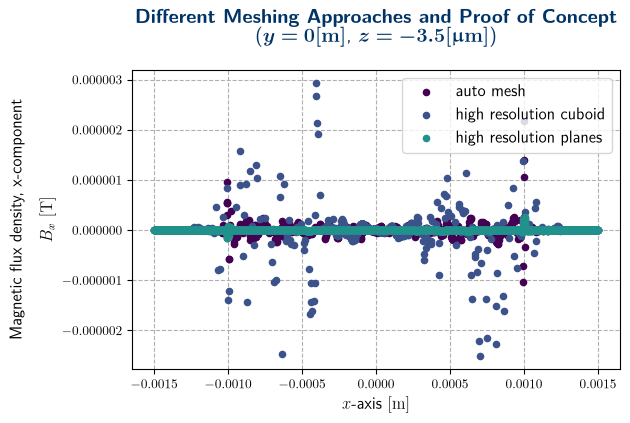

In [ ]:
fraction = 1
xparam = "x"
for yparam in y_axis_params:
    if xparam not in group_longitudinal[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_longitudinal[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_longitudinal[midx][[xparam, yparam]].copy()
            mask = group_longitudinal[midx]["z"] == z_value
            df_plot = df_plot[mask]
            mask = df_plot[xparam].abs() <= length_limit
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_01_00 + r" ($\bm{y = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,
                    )

        # Theory
        if True and "mf.B" in yparam:
            idx = THEORY_FORMULA[yparam]
            fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6, z_pos=z_value) 

        fig, ax = apf.plot_background(fig, ax)
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )

        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## xy-plane

In [ ]:
output_folder = group_output_folder / "xy plane"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_xy_plane = []
z_values = []
for midx in range(group_length):
    # get all xy_plane dataframes
    xy_plane = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{XY_PLANE_END}"
    xy_plane_header_data, xy_plane_df = cdi.read_comsol_export(str(xy_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    xy_plane_df["z"] = cdi.round_to_6_sig_digits(xy_plane_df["z"])
    z_values.extend(xy_plane_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    xy_plane_df["T (K)"] = xy_plane_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in xy_plane_df.columns else xy_plane_df["T (K)"]
    group_xy_plane.append(xy_plane_df)

In [ ]:
z_value = np.mean(z_values)
print(f"z_value: {z_value}")

z_value: 0.0


In [ ]:
# mask = df_parameters["name"] == "conductor_all_length"
mask = df_parameters["name"] == "substrate_length"
length_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

# mask = df_parameters["name"] == "conductor_all_width"
mask = df_parameters["name"] == "substrate_width"
width_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params:
    if xparam not in group_xy_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_xy_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_xy_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_xy_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_01_00 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

## conductor-plane

In [ ]:
output_folder = group_output_folder / "conductor plane"

if len(y_axis_params_con_plane) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_conductor_plane = []
z_values = []
for midx in range(group_length):
    # get all conductor_plane dataframes
    conductor_plane = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{CONDUCTOR_PLANE_END}"
    conductor_plane_header_data, conductor_plane_df = cdi.read_comsol_export(str(conductor_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    conductor_plane_df["z"] = cdi.round_to_6_sig_digits(conductor_plane_df["z"])
    z_values.extend(conductor_plane_df["z"].dropna().unique())

    group_conductor_plane.append(conductor_plane_df)

In [ ]:
z_value = np.mean(z_values)
print(f"z_value: {z_value}")

z_value: 5e-07


In [ ]:
# mask = df_parameters["name"] == "conductor_all_length"
mask = df_parameters["name"] == "substrate_length"
length_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

# mask = df_parameters["name"] == "conductor_all_width"
mask = df_parameters["name"] == "substrate_width"
width_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params_con_plane:
    if xparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_conductor_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_01_00 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,

                    squared = True,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

# 02_00-H Designs

## BASE

In [513]:
group_input_folder = INPUT_FOLDER / FOLDER_02_00
group_output_folder = OUTPUT_FOLDER / FOLDER_02_00

In [514]:
group_length = len(MODELS_02_00)

group_model = []
group_label = []
group_terminals = []
group_parameters = []
for midx in range(group_length):
    # get all modelnames
    group_model.append(MODELS_02_00[midx])
    group_label.append(MODELS_02_00[midx].split('-')[-1])

    # get all terminal dataframes
    terminals = group_input_folder/ MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{TERMINAL_END}"
    df_terminal = pd.read_csv(terminals)
    group_terminals.append(df_terminal)

    # get all parameter dataframes
    parameters = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{PARAMETER_END}"
    df_parameters = pd.read_csv(parameters).drop(labels = "description", axis = 1)
    group_parameters.append(df_parameters)

In [515]:
df_parameters = group_parameters[0]  # assuming constant parameters (besides meshing)

In [516]:
display(group_label)

['H design with minimized insulator', 'H design with full insulator']

In [517]:
y_axis_params = [
    "mf.Bx (T)",
    "mf.By (T)",
    "mf.Bz (T)",
    "T (K)",
]
y_axis_params_con_plane = [
    # "ec.Jx (A/m^2)",
    # "ec.Jy (A/m^2)",
    # "ec.Jz (A/m^2)",
    # "V (V)",
] 

In [518]:
def add_magnetic_theory(
        fig: matplotlib.figure.Figure,
        ax: matplotlib.axes.Axes,
        df_parameters: pd.DataFrame,
        xparam: str,
        Bidx: int,
        discretization_length:float = 3e-6,
        z_pos: float | None = None,
        )-> tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Add a theoretical magnetic field curve to the provided matplotlib axis based on the Biot-Savart law.
    
    Args:
        fig (matplotlib.figure.Figure):             The matplotlib figure object.
        ax (matplotlib.axes.Axes):                  The matplotlib axes object where the theory curve will be added.
        df_parameters (pd.DataFrame):               DataFrame containing the necessary parameters for the Biot-Savart law calculation.
        Bidx (int):                                 Index indicating which component of the magnetic field to plot (0 for Bx, 1 for By, 2 for Bz).
        discretization_length (float, optional):    Minimum discretization length for the x-limits. Defaults to 3e-6.
        z_pos (float | None, optional):             Optional z-position for the theory curve. If None, the z-position will be determined based on the xparam. Defaults to None.
        
    Returns:
        tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]: The updated figure and axes objects with the theory curve added.
    """
    if xparam not in ["x", "y", "z"]:
        print(f"Warning: xparam '{xparam}' not in ['x', 'y', 'z']. Skipping theory curve generation.")
        return fig, ax 

    # Get the x-coordinates of all scatter points and lines in the current axis
    all_x_data = []
    for collection in ax.collections:
        offsets = collection.get_offsets() # get the coordinates of the scatter points
        all_x_data.extend(offsets[:, 0]) # extend the list with the x-coordinates
    for line in ax.get_lines():
        all_x_data.extend(line.get_xdata()) # extend the list with the x-coordinates of the lines

    # Determine the x-limits based on the data
    if all_x_data:
        xlimits = [min(all_x_data), max(all_x_data)]
    else: 
        xlimits = list(ax.get_xlim()) # fallback to the current axis limits if no data is found

    # apply a minimum discretization length to the x-limits
    if xparam == "z":
        for i in range(2):
            if abs(xlimits[i]) < 0.5*discretization_length:
                xlimits[i] = np.sign(xlimits[i]) * 0.8*discretization_length

    # Check if the x-limits are equal, which would prevent generating a theory curve
    if xlimits[0] == xlimits[1]:
        raise ValueError("xlimits are equal, cannot generate theory curve.")
    
    # Generate x values for the theory curve
    x = np.linspace(xlimits[0], xlimits[1], THEORY_PLOT_POINTS)

    # extract the necessary parameters from the DataFrame for the Biot-Savart law calculation
    # conductor A
    mask = df_parameters["name"] == "conductor_A_length"
    conA_length = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "conductor_A_width"
    conA_width = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    numA_w = 2 * max(round(conA_width / discretization_length), 1)

    mask = df_parameters["name"] == "conductor_A_height"
    conA_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    numA_h = 2 * max(round(conA_height / discretization_length), 1)

    # conductor B
    mask = df_parameters["name"] == "conductor_B_length"
    conB_length = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "conductor_B_width"
    conB_width = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    numB_w = 2 * max(round(conB_width / discretization_length), 1)

    mask = df_parameters["name"] == "conductor_B_height"
    conB_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
    numB_h = 2 * max(round(conB_height / discretization_length), 1)

    mask = df_parameters["name"] == "epilayer_height"
    conB_height_offset = -1 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

    conB_width_offset = 0.0
    mask = df_parameters["name"] == "epilayer_width"
    conB_width_offset += 0.5 * df_parameters.loc[mask, "evaluated_value"].iloc[0]
    mask = df_parameters["name"] == "conductor_epilayer_distance"
    conB_width_offset += df_parameters.loc[mask, "evaluated_value"].iloc[0]
    conB_width_offset += 0.5 * conB_width

    # currents
    mask = df_parameters["name"] == "I_conductor_A_terminal"
    I_conA = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "I_conductor_B_minus_terminal"
    I_conBm = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "I_conductor_B_plus_terminal"
    I_conBp = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    # calculate conductor arm points
    mask = df_parameters["name"] == "arm_angle_B"
    conB_angle = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "substrate_width"
    substrate_width = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    mask = df_parameters["name"] == "substrate_length"
    substrate_length = df_parameters.loc[mask, "evaluated_value"].iloc[0]

    ## get the overshoot of the arm in x and y directions
    xovershoot_arm = np.abs(np.cos(conB_angle) +0.5*conB_length - 0.5*substrate_length)
    yovershoot_arm = np.abs(np.sin(conB_angle) +conB_width_offset - 0.5*substrate_width)

    ## calculate the arm length by limiting the arm to the substrate dimensions
    r_0 = 0
    r_1 = 1
    if xovershoot_arm > yovershoot_arm:
        xr = np.abs(0.5*substrate_length - 0.5*conB_length)
        r_1 = xr / np.cos(conB_angle)
    else:
        yr = np.abs(0.5*substrate_width - conB_width_offset)
        r_1 = yr / np.sin(conB_angle)
    
    # calculate the points of the conductor arms in 3D space
    p0_pp = ((r_0 * np.cos(conB_angle)+0.5*conB_length), (r_0*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))
    p1_pp = ((r_1 * np.cos(conB_angle)+0.5*conB_length), (r_1*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))

    p0_mp = (-(r_0 * np.cos(conB_angle)+0.5*conB_length), (r_0*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))
    p1_mp = (-(r_1 * np.cos(conB_angle)+0.5*conB_length), (r_1*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))

    p0_mm = (-(r_0 * np.cos(conB_angle)+0.5*conB_length), -(r_0*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))
    p1_mm = (-(r_1 * np.cos(conB_angle)+0.5*conB_length), -(r_1*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))

    p0_pm = ((r_0 * np.cos(conB_angle)+0.5*conB_length), -(r_0*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))
    p1_pm = ((r_1 * np.cos(conB_angle)+0.5*conB_length), -(r_1*np.sin(conB_angle)+conB_width_offset), (conB_height_offset+0.5*conB_height))

    # calculate the points of the main conductors in 3D space
    conA_p0 = (0.5*conA_length, 0, 0.5*conA_height)
    conA_p1 = (-0.5*conA_length, 0, 0.5*conA_height)

    conBp_p0 = (0.5*conB_length, conB_width_offset, conB_height_offset+0.5*conB_height)
    conBp_p1 = (-0.5*conB_length, conB_width_offset, conB_height_offset+0.5*conB_height)

    conBm_p0 = (0.5*conB_length, -1*conB_width_offset, conB_height_offset+0.5*conB_height)
    conBm_p1 = (-0.5*conB_length, -1*conB_width_offset, conB_height_offset+0.5*conB_height)


    # get y values
    y = [np.nan] * len(x)
    for i, x_val in enumerate(x):
        # Determine the position
        z_pos = z_pos if z_pos is not None else 0.0
        pos = (0, 0, 0)
        if xparam == "x":
            pos = (x_val, 0, z_pos)
        if xparam == "y":
            pos = (0, x_val, z_pos)
        if xparam == "z":
            pos = (0, 0, x_val)

        # Calculate the magnetic field using the Biot-Savart law
        B = np.zeros(3) # initialize the magnetic field vector using numpy array for easy addition

        # main conductors
        B_A = tfm.biot_savart_rectangular_conductor(
            pos = pos,    
            R_con = [conA_p0, conA_p1],
            I = I_conA,
            width_vec = (0, conA_width, 0),
            height_vec = (0, 0, conA_height),
            num_w = numA_w,
            num_h = numA_h,           
        )
        B += np.array(B_A)

        B_BP = tfm.biot_savart_rectangular_conductor(
                    pos = pos,    
                    R_con = [conBp_p0, conBp_p1],
                    I = I_conBp,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,           
                )
        B += np.array(B_BP)
        
        B_BM = tfm.biot_savart_rectangular_conductor(
                    pos = pos,    
                    R_con = [conBm_p0, conBm_p1],
                    I = I_conBm,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,           
                )
        B += np.array(B_BM)

        # arm conductors
        B_PP_arm = tfm.biot_savart_rectangular_conductor(
                    pos = pos,
                    R_con = [p0_pp, p1_pp],
                    I = I_conBp,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,
                )
        B += np.array(B_PP_arm)

        B_MP_arm = tfm.biot_savart_rectangular_conductor(
                    pos = pos,
                    R_con = [p0_mp, p1_mp],
                    I = I_conBp,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,
                )
        B += np.array(B_MP_arm)

        B_MM_arm = tfm.biot_savart_rectangular_conductor(
                    pos = pos,
                    R_con = [p0_mm, p1_mm],
                    I = I_conBm,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,
                )
        B += np.array(B_MM_arm)

        B_PM_arm = tfm.biot_savart_rectangular_conductor(
                    pos = pos,
                    R_con = [p0_pm, p1_pm],
                    I = I_conBm,
                    width_vec = (0, conB_width, 0),
                    height_vec = (0, 0, conB_height),
                    num_w = numB_w,
                    num_h = numB_h,
                )
        B += np.array(B_PM_arm)

        y[i]=B[Bidx]
        

    ax.plot(x, y, label=fr"Biot-Savart: 3 straight conductors", color="tab:red")#, s=apf.MARKERSIZE)

    return fig, ax

## z-axis (depth)

In [ ]:
output_folder = group_output_folder / "z axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_depth = []
for midx in range(group_length):
    # get all depth dataframes
    depth = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{DEPTH_END}"
    depth_header_data, depth_df = cdi.read_comsol_export(str(depth))

    # drop the x and y columns, as they are not needed for depth plots
    depth_df.drop(labels=["x", "y"], axis=1, inplace=True)

    # adjust the temperature values to be relative to T_0
    depth_df["T (K)"] = depth_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in depth_df.columns else depth_df["T (K)"]
    group_depth.append(depth_df)

In [ ]:
fraction = 1
xparam = "z"
for yparam in y_axis_params:
    if xparam not in group_depth[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_depth[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    # create figure and axis for plotting
    fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

        
    # Data
    cmap = mpl.colormaps['viridis'] # type: ignore
    
    for midx in range(group_length):
               
        df_plot = group_depth[midx][[xparam, yparam]].copy()
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = None,

                    label = group_label[midx],
                    color = cmap(midx / group_length),
                    translation_dict = TRANSLATE_PLOTLABELS,

                    fig = fig,
                    ax = ax,

                    title = GROUPNAME_02_00 + r" ($\bm{x = 0 [\mathrm{m}]}$, $\bm{y = 0 [\mathrm{m}]}$)",
                    x_label = xparam,
                    y_label = yparam,
                )

    # Theory
    if True and "mf.B" in yparam:
        idx = THEORY_FORMULA[yparam]
        fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6)

    if False and "T (K)" in yparam:
        fig, ax = add_temperature_theory(fig, ax, df_parameters, xparam=xparam, df_layer=df_conductivity)

    fig, ax = apf.plot_background(fig, ax)
    
    ax.legend(
        loc="upper center", 
        bbox_to_anchor=(0.5, -0.15/fraction), 
        ncol=2
        )
    clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
    apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}")

## y-axis (homogenity)

In [ ]:
output_folder = group_output_folder / "y axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_homogenity = []
unique_z_values = []
for midx in range(group_length):
    # get all homogenity dataframes
    homogenity = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{HOMOGENEITY_END}"
    homogenity_header_data, homogenity_df = cdi.read_comsol_export(str(homogenity))

    # drop the x column, as it is not needed for homogenity plots
    homogenity_df.drop(labels=["x"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    homogenity_df["z"] = cdi.round_to_6_sig_digits(homogenity_df["z"])
    unique_z_values.extend(homogenity_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    homogenity_df["T (K)"] = homogenity_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in homogenity_df.columns else homogenity_df["T (K)"]
    group_homogenity.append(homogenity_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
mask = df_parameters["name"] == "insulator_height"
insulator_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
print(f"insulator_height: {insulator_height}")

insulator_height: 5.000000000000001e-07


In [ ]:
display(unique_z_values)

[np.float64(-1.05e-05),
 np.float64(-9.5e-06),
 np.float64(-8.5e-06),
 np.float64(-7.5e-06),
 np.float64(-6.5e-06),
 np.float64(-5.5e-06),
 np.float64(-4.5e-06),
 np.float64(-3.5e-06),
 np.float64(-2.5e-06),
 np.float64(-1.5e-06),
 np.float64(-5e-07)]

In [ ]:
plot_z_values = [-3e-06] - insulator_height

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.5e-06])

In [ ]:
conB_width_offset = 0.0
mask = df_parameters["name"] == "epilayer_width"
conB_width_offset += 0.5 * df_parameters.loc[mask, "evaluated_value"].iloc[0]
mask = df_parameters["name"] == "conductor_epilayer_distance"
conB_width_offset += df_parameters.loc[mask, "evaluated_value"].iloc[0]
mask = df_parameters["name"] == "conductor_B_width"
conB_width_offset += 0.5 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

width_limit = 1.5 * conB_width_offset

In [ ]:
fraction = 1
xparam = "y"
for yparam in y_axis_params:
    if xparam not in group_homogenity[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_homogenity[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_homogenity[midx][[xparam, yparam]].copy()
            mask = group_homogenity[midx]["z"] == z_value
            df_plot = df_plot[mask]
            mask = df_plot[xparam].abs() <= width_limit
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_02_00 + r" ($\bm{x = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,
                    )

        # Theory
        if True and "mf.B" in yparam:
            idx = THEORY_FORMULA[yparam]
            fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6, z_pos=z_value) 

        if False and "T (K)" in yparam:
            fig, ax = add_temperature_theory(fig, ax, df_parameters, xparam=xparam, df_layer=df_conductivity, z_pos=z_value)

        fig, ax = apf.plot_background(fig, ax)
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )
        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## x-axis (longitudinal)

In [ ]:
output_folder = group_output_folder / "x axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_longitudinal = []
unique_z_values = []
for midx in range(group_length):
    # get all longitudinal dataframes
    longitudinal = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{LONGITUDINAL_END}"
    longitudinal_header_data, longitudinal_df = cdi.read_comsol_export(str(longitudinal))

    # drop the y column, as it is not needed for longitudinal plots
    longitudinal_df.drop(labels=["y"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    longitudinal_df["z"] = cdi.round_to_6_sig_digits(longitudinal_df["z"])
    unique_z_values.extend(longitudinal_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    longitudinal_df["T (K)"] = longitudinal_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in longitudinal_df.columns else longitudinal_df["T (K)"]
    group_longitudinal.append(longitudinal_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
mask = df_parameters["name"] == "insulator_height"
insulator_height = df_parameters.loc[mask, "evaluated_value"].iloc[0]
print(f"insulator_height: {insulator_height}")

insulator_height: 5.000000000000001e-07


In [ ]:
display(unique_z_values)

[np.float64(-1.05e-05),
 np.float64(-9.5e-06),
 np.float64(-8.5e-06),
 np.float64(-7.5e-06),
 np.float64(-6.5e-06),
 np.float64(-5.5e-06),
 np.float64(-4.5e-06),
 np.float64(-3.5e-06),
 np.float64(-2.5e-06),
 np.float64(-1.5e-06),
 np.float64(-5e-07)]

In [ ]:
plot_z_values = [-3e-06] - insulator_height

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.5e-06])

In [ ]:
mask = df_parameters["name"] == "conductor_A_length"
length_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "x"
for yparam in y_axis_params:
    if xparam not in group_longitudinal[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_longitudinal[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_longitudinal[midx][[xparam, yparam]].copy()
            mask = group_longitudinal[midx]["z"] == z_value
            df_plot = df_plot[mask]
            mask = df_plot[xparam].abs() <= length_limit
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_02_00 + r" ($\bm{y = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,
                    )

        # Theory
        if True and "mf.B" in yparam:
            idx = THEORY_FORMULA[yparam]
            fig, ax = add_magnetic_theory(fig, ax, df_parameters, xparam=xparam, Bidx=idx, discretization_length=3e-6, z_pos=z_value) 

        fig, ax = apf.plot_background(fig, ax)
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )

        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## xy-plane

In [519]:
output_folder = group_output_folder / "xy plane"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [520]:
group_xy_plane = []
z_values = []
for midx in range(group_length):
    # get all xy_plane dataframes
    xy_plane = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{XY_PLANE_END}"
    xy_plane_header_data, xy_plane_df = cdi.read_comsol_export(str(xy_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    xy_plane_df["z"] = cdi.round_to_6_sig_digits(xy_plane_df["z"])
    z_values.extend(xy_plane_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    xy_plane_df["T (K)"] = xy_plane_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in xy_plane_df.columns else xy_plane_df["T (K)"]
    group_xy_plane.append(xy_plane_df)

In [521]:
z_value = np.mean(z_values)
print(f"z_value: {z_value}")

z_value: -1e-05


In [522]:
# mask = df_parameters["name"] == "conductor_all_length"
mask = df_parameters["name"] == "substrate_length"
length_limit = 1/3 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

# mask = df_parameters["name"] == "conductor_all_width"
mask = df_parameters["name"] == "substrate_width"
width_limit = 1/3 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [523]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params:
    if xparam not in group_xy_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_xy_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_xy_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_xy_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_02_00 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,

                    squared = True,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

## conductor-plane

In [ ]:
output_folder = group_output_folder / "conductor plane"

if len(y_axis_params_con_plane) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_conductor_plane = []
z_values = []
for midx in range(group_length):
    # get all conductor_plane dataframes
    conductor_plane = group_input_folder / MODELS_02_00[midx] / DATA_EXPORT / f"{MODELS_02_00[midx]}{CONDUCTOR_PLANE_END}"
    conductor_plane_header_data, conductor_plane_df = cdi.read_comsol_export(str(conductor_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    conductor_plane_df["z"] = cdi.round_to_6_sig_digits(conductor_plane_df["z"])
    z_values.extend(conductor_plane_df["z"].dropna().unique())

    group_conductor_plane.append(conductor_plane_df)

In [ ]:
z_value = np.mean(z_values)
print(f"z_value: {z_value}")

z_value: 5e-07


In [ ]:
# mask = df_parameters["name"] == "conductor_all_length"
mask = df_parameters["name"] == "substrate_length"
length_limit = 1/3 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

# mask = df_parameters["name"] == "conductor_all_width"
mask = df_parameters["name"] == "substrate_width"
width_limit = 1/3 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params_con_plane:
    if xparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_conductor_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_02_00 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,

                    squared = True,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

# 01_01-Coil Designs

## BASE

In [ ]:
group_input_folder = INPUT_FOLDER / FOLDER_01_XX
group_output_folder = OUTPUT_FOLDER / FOLDER_01_XX / FOLDER_01_01

In [ ]:
group_length = len(MODELS_01_01)

group_model = []
group_label = []
group_terminals = []
group_parameters = []
for midx in range(group_length):
    # get all modelnames
    group_model.append(MODELS_01_01[midx])
    group_label.append(MODELS_01_01[midx].split('-')[-1])

    # get all terminal dataframes
    terminals = group_input_folder/ MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{TERMINAL_END}"
    df_terminal = pd.read_csv(terminals)
    group_terminals.append(df_terminal)

    # get all parameter dataframes
    parameters = group_input_folder / MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{PARAMETER_END}"
    df_parameters = pd.read_csv(parameters).drop(labels = "description", axis = 1)
    group_parameters.append(df_parameters)

In [ ]:
df_parameters = group_parameters[0]  # assuming constant parameters (besides meshing)

In [ ]:
display(group_label)

['Round spiral', 'Rectangular spiral']

In [ ]:
y_axis_params = [
    "mf.Bx (T)",
    "mf.By (T)",
    "mf.Bz (T)",
]
y_axis_params_con_plane = [
    # "ec.Jx (A/m^2)",
    # "ec.Jy (A/m^2)",
    # "ec.Jz (A/m^2)",
    # "V (V)",
] 

## z-axis (depth)

In [ ]:
output_folder = group_output_folder / "z axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_depth = []
for midx in range(group_length):
    # get all depth dataframes
    depth = group_input_folder / MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{DEPTH_END}"
    depth_header_data, depth_df = cdi.read_comsol_export(str(depth))

    # drop the x, y and T (K) columns, as they are not needed for depth plots
    depth_df.drop(labels=["x", "y", "T (K)"], axis=1, inplace=True)
    
    group_depth.append(depth_df)

In [ ]:
fraction = 1
xparam = "z"
for yparam in y_axis_params:
    if xparam not in group_depth[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_depth[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    # create figure and axis for plotting
    fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

        
    # Data
    cmap = mpl.colormaps['viridis'] # type: ignore
    
    for midx in range(group_length):
               
        df_plot = group_depth[midx][[xparam, yparam]].copy()
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = None,

                    label = group_label[midx],
                    color = cmap(midx / group_length),
                    translation_dict = TRANSLATE_PLOTLABELS,

                    fig = fig,
                    ax = ax,

                    title = GROUPNAME_01_01 + r" ($\bm{x = 0 [\mathrm{m}]}$, $\bm{y = 0 [\mathrm{m}]}$)",
                    x_label = xparam,
                    y_label = yparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                )
    
    ax.legend(
        loc="upper center", 
        bbox_to_anchor=(0.5, -0.15/fraction), 
        ncol=2
        )
    clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
    apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}")

## y-axis (homogenity)

In [ ]:
output_folder = group_output_folder / "y axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_homogenity = []
unique_z_values = []
for midx in range(group_length):
    # get all homogenity dataframes
    homogenity = group_input_folder / MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{HOMOGENEITY_END}"
    homogenity_header_data, homogenity_df = cdi.read_comsol_export(str(homogenity))

    # drop the x and T (K) columns, as they are not needed for homogenity plots
    homogenity_df.drop(labels=["x", "T (K)"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    homogenity_df["z"] = cdi.round_to_6_sig_digits(homogenity_df["z"])
    unique_z_values.extend(homogenity_df["z"].dropna().unique())

    group_homogenity.append(homogenity_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
display(unique_z_values)

[np.float64(-1e-05),
 np.float64(-9e-06),
 np.float64(-8e-06),
 np.float64(-7e-06),
 np.float64(-6e-06),
 np.float64(-5e-06),
 np.float64(-4e-06),
 np.float64(-3e-06),
 np.float64(-2e-06),
 np.float64(-1e-06),
 np.float64(0.0)]

In [ ]:
plot_z_values = [-3e-06]

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.e-06])

In [ ]:
fraction = 1
xparam = "y"
for yparam in y_axis_params:
    if xparam not in group_homogenity[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_homogenity[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_homogenity[midx][[xparam, yparam]].copy()
            mask = group_homogenity[midx]["z"] == z_value
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_01_01 + r" ($\bm{x = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,

                        xstyle = 'prefix',
                        ystyle = 'prefix',
                    )
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )
        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## x-axis (longitudinal)

In [ ]:
output_folder = group_output_folder / "x axis"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_longitudinal = []
unique_z_values = []
for midx in range(group_length):
    # get all longitudinal dataframes
    longitudinal = group_input_folder / MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{LONGITUDINAL_END}"
    longitudinal_header_data, longitudinal_df = cdi.read_comsol_export(str(longitudinal))

    # drop the y column, as it is not needed for longitudinal plots
    longitudinal_df.drop(labels=["y"], axis=1, inplace=True)

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    longitudinal_df["z"] = cdi.round_to_6_sig_digits(longitudinal_df["z"])
    unique_z_values.extend(longitudinal_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    longitudinal_df["T (K)"] = longitudinal_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in longitudinal_df.columns else longitudinal_df["T (K)"]
    group_longitudinal.append(longitudinal_df)

unique_z_values = sorted(list(set(unique_z_values))) # get unique z values across all models and sort them and get rid of duplicates

In [ ]:
display(unique_z_values)

[np.float64(-1e-05),
 np.float64(-9e-06),
 np.float64(-8e-06),
 np.float64(-7e-06),
 np.float64(-6e-06),
 np.float64(-5e-06),
 np.float64(-4e-06),
 np.float64(-3e-06),
 np.float64(-2e-06),
 np.float64(-1e-06),
 np.float64(0.0)]

In [ ]:
plot_z_values = [-3e-06]

# Round the z values to 6 significant figures to avoid floating point issues when comparing with unique_z_values
positive_values = np.where(plot_z_values == 0, 1e-20, np.abs(plot_z_values))
exponent = np.floor(np.log10(positive_values)) # get magnitude 
factor = 10 ** (5 - exponent) # shift factor
plot_z_values = np.round(plot_z_values * factor) / factor # round shifted values and shift back
plot_z_values = np.where(plot_z_values == 0.0, 0.0, plot_z_values) 

display(plot_z_values)
for z_value in plot_z_values:
    if z_value not in unique_z_values:
        print(f"{z_value} is not a valid z value.")

array([-3.e-06])

In [ ]:
fraction = 1
xparam = "x"
for yparam in y_axis_params:
    if xparam not in group_longitudinal[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_longitudinal[0].columns:
        print(f"Skipping '{yparam}'.")
        continue

    for z_value in plot_z_values:
        # create figure and axis for plotting
        fig, ax = apf.get_fig_ax(fraction_textwidth=fraction)

            
        # Data
        cmap = mpl.colormaps['viridis'] # type: ignore
        
        for midx in range(group_length):
                
            df_plot = group_longitudinal[midx][[xparam, yparam]].copy()
            mask = group_longitudinal[midx]["z"] == z_value
            df_plot = df_plot[mask]

            z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
            z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)

            fig, ax = cdp.standard_scatter_plot_df(
                        df = df_plot,
                        x = xparam,
                        y = yparam,
                        z = None,

                        label = group_label[midx],
                        color = cmap(midx / group_length),
                        translation_dict = TRANSLATE_PLOTLABELS,

                        fig = fig,
                        ax = ax,

                        title = GROUPNAME_01_01 + r" ($\bm{y = 0 [\mathrm{m}]}$, " + z_value_str + ")",
                        x_label = xparam,
                        y_label = yparam,

                        xstyle = 'prefix',
                        ystyle = 'prefix'
                    )
        
        ax.legend(
            loc="upper center", 
            bbox_to_anchor=(0.5, -0.15/fraction), 
            ncol=2
            )

        clean_yparam = re.sub(r"\s*\(.*?\)", "", str(yparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{clean_yparam}_over_{xparam}-{z_value}")

## xy-plane

In [ ]:
output_folder = group_output_folder / "xy plane"

if len(y_axis_params) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_xy_plane = []
z_values = []
for midx in range(group_length):
    # get all xy_plane dataframes
    xy_plane = group_input_folder / MODELS_01_01[midx] / DATA_EXPORT / f"{MODELS_01_01[midx]}{XY_PLANE_END}"
    xy_plane_header_data, xy_plane_df = cdi.read_comsol_export(str(xy_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    xy_plane_df["z"] = cdi.round_to_6_sig_digits(xy_plane_df["z"])
    z_values.extend(xy_plane_df["z"].dropna().unique())

    # adjust the temperature values to be relative to T_0
    xy_plane_df["T (K)"] = xy_plane_df["T (K)"].apply(lambda T: T - T_0) if "T (K)" in xy_plane_df.columns else xy_plane_df["T (K)"]
    group_xy_plane.append(xy_plane_df)

In [ ]:
z_value = np.mean(z_values)
if abs(z_value) < 1e-16:
    z_value = 0.0
print(f"z_value: {z_value}")

z_value: 0.0


In [ ]:
mask = df_parameters["name"] == "conductor_all_length"
length_limit = 1 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

mask = df_parameters["name"] == "conductor_all_length"
width_limit = 1 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
print(f"length_limit: {length_limit}")
print(f"width_limit: {width_limit}")

length_limit: 0.00025
width_limit: 0.00025


In [ ]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params:
    if xparam not in group_xy_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_xy_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_xy_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_xy_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_01_01 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,

                    squared = True,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

## conductor-plane

In [ ]:
output_folder = group_output_folder / "conductor plane"

if len(y_axis_params_con_plane) > 0:
    makedirs(output_folder, exist_ok=True)  # create output folder if it doesn't exist

In [ ]:
group_conductor_plane = []
z_values = []
for midx in range(group_length):
    # get all conductor_plane dataframes
    conductor_plane = group_input_folder / MODELS_01_00[midx] / DATA_EXPORT / f"{MODELS_01_00[midx]}{CONDUCTOR_PLANE_END}"
    conductor_plane_header_data, conductor_plane_df = cdi.read_comsol_export(str(conductor_plane))

    # round the z values to 6 significant digits to avoid floating point issues when comparing unique values
    conductor_plane_df["z"] = cdi.round_to_6_sig_digits(conductor_plane_df["z"])
    z_values.extend(conductor_plane_df["z"].dropna().unique())

    group_conductor_plane.append(conductor_plane_df)

In [ ]:
z_value = np.mean(z_values)
print(f"z_value: {z_value}")

z_value: 5e-07


In [ ]:
# mask = df_parameters["name"] == "conductor_all_length"
mask = df_parameters["name"] == "substrate_length"
length_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

# mask = df_parameters["name"] == "conductor_all_width"
mask = df_parameters["name"] == "substrate_width"
width_limit = 1.5 / 2 * df_parameters.loc[mask, "evaluated_value"].iloc[0]

In [ ]:
fraction = 1
xparam = "x"
yparam = "y"
for zparam in y_axis_params_con_plane:
    if xparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{xparam}'.")
        continue
    if yparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{yparam}'.")
        continue
    if zparam not in group_conductor_plane[0].columns:
        print(f"Skipping '{zparam}'.")
        continue

    for midx in range(group_length):
        df_plot = group_conductor_plane[midx][[xparam, yparam, zparam]].copy()
        df_plot = df_plot.dropna()
        df_plot = df_plot[(df_plot[xparam].abs() <= length_limit) & (df_plot[yparam].abs() <= width_limit)]

        z_value_str = r"$\bm{z =" + f" {z_value}" + r" [\mathrm{m}]}$"
        z_value_str = apf.set_prefix_in_number_unit_string(z_value_str, bm=True)
        fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    z = zparam,

                    translation_dict = TRANSLATE_PLOTLABELS,

                    title = GROUPNAME_01_00 + f" ({group_label[midx]}, " + z_value_str + ")",
                    x_label = xparam,
                    y_label = yparam,
                    z_label = zparam,

                    xstyle = 'prefix',
                    ystyle = 'prefix',
                    zstyle = 'prefix',
                    markersize = 0.002*apf.MARKERSIZE,

                    squared = True,
                )
        clean_zparam = re.sub(r"\s*\(.*?\)", "", str(zparam)) # remove any text in parentheses and leading/trailing whitespace
        apf.save_figure(fig, path = output_folder / f"{group_label[midx]}-{clean_zparam}_over_{xparam}{yparam}_plane-{z_value}")

# Archiv

In [ ]:
raise SystemExit("End of script reached.")

SystemExit: End of script reached.

C:\Users\ad06ovod\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
xparam = "z"
for yparam in Y_AXIS_PARAMS:
    if yparam in depth_df.columns:
        df_plot = depth_df[[xparam, yparam]].copy()
        
        fig, ax = cdp.standard_scatter_plot_df(
            df = df_plot,
            x = xparam,
            y = yparam,
            label = "Data",
            translation_dict = TRANSLATE_PLOTLABELS,
            fraction_textwidth = 1.0,
            title = f"{modeltitle.split('-')[-1]}" + r" ($\bm{x}$ = 0 [m], $\bm{y}$ = 0 [m])",
            x_label = xparam,
            y_label = yparam,
        )

        df_layer = pd.DataFrame({
            "name": ["conductor", "insulator", "epilayer", "substrate"],
            "width": [15e-6, 15e-6, 15e-6, 3e-3],  # width in meters
            "thickness": [1e-6, 500e-9, 10e-6, 50e-6],  # thickness in meters
            "thermal_conductivity": [429, 1.38, 450, 450],  # thermal conductivity in W/(m·K)
        })
        
        x = df[xparam].astype(float).tolist()
        y = [np.nan] * len(x)  # initialize y with NaN values
        if yparam == "T (K)":
            power = tfm.power_per_length(
                    I = 5e-3,
                    sigma = 61.6e6,
                    h = df_layer[df_layer["name"] == "conductor"]["thickness"].values[0],
                    w = df_layer[df_layer["name"] == "conductor"]["width"].values[0],
                )
            print(f"Calculated power per length: {power} W/m")
            T = [np.nan] * len(x)
            for x_val in x:
                T[x.index(x_val)] = tfm.temp_est_line_source_approximation(
                        df = df_layer,
                        power_per_length = power,
                        z = x_val,
                        y = 0.0,
                        T_iso = 293.15,
                    )
            y = T
            y = [t - 293.15 for t in T]
            # y = [t + 216e-6 for t in T]
            ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
            ax.legend(loc='best')
        if "mf.B" in yparam:
            idx = THEORY_FORMULA[yparam]
            y = [np.nan] * len(x)
            for x_val in x:
                r_cond = (-1.5e-3, (+0.5*15e-6+0.5*15e-6+0.2*15e-6),-(500e-9+10e-6-0.5e-6))
                B = tfm.biot_savart_vec_theo(
                    pos = (0, 0, x_val),    
                    R_con = [(r_cond[0], 0, 0), (-r_cond[0], 0, 0)],  
                    I = -5e-3,           
                )
                B += tfm.biot_savart_vec_theo(
                    pos = (0, 0, x_val),    
                    R_con = [(0.5*r_cond[0], r_cond[1], r_cond[1]), (-0.5*r_cond[0], r_cond[1], r_cond[1])]
                    I = +10e-3,           
                )
                B += tfm.biot_savart_vec_theo(
                    pos = (0, 0, x_val),    
                    R_con = [(0.5*r_cond[0], -r_cond[1], r_cond[1]), (-0.5*r_cond[0], -r_cond[1], r_cond[1]
                    I = +10e-3, 
                )          
                y[x.index(x_val)]=B[idx]
            ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
            ax.legend(loc='best')
        plt.show()
        tl.log_message(f"Finished plotting of {yparam} vs {xparam}")

In [ ]:
# get a list of all txt files in the "Data Export" subfolder
txt_files = list(input_folder.glob("*.txt"))
for txt_file in txt_files:

    header_data, df = cdi.read_comsol_export(str(txt_file))
    
    modelstem = str(header_data.get('Model')).replace(".mph", "")
    title_match = re.match(r"(.*)-(.*)-.*", modelstem)
    modeltitle = title_match.group(2) if title_match else modelstem
    if re.match(r".*-depth_exported_data$", txt_file.stem):
        df.drop(labels=["x", "y"], axis=1, inplace=True)
        depth_folder = output_folder / "z axis"
        makedirs(depth_folder, exist_ok=True)  # create output folder if it doesn't exist
        xparam = "z"
        for yparam in Y_AXIS_PARAMS:
            if yparam in df.columns:
                tl.log_message(f"Started plotting of {yparam} vs {xparam}")
                df_plot = df[[xparam, yparam]].copy()
                if yparam == "T (K)":
                    df_plot[yparam] = df_plot[yparam] - 293.15 
                fig, ax = cdp.standard_scatter_plot_df(
                    df = df_plot,
                    x = xparam,
                    y = yparam,
                    label = "Data",
                    translation_dict = TRANSLATE_PLOTLABELS,
                    fraction_textwidth = 1.0,
                    title = f"{modeltitle.split('-')[-1]}" + r" ($\bm{x}$ = 0 [m], $\bm{y}$ = 0 [m])",
                    x_label = xparam,
                    y_label = yparam,
                )
                df_layer = pd.DataFrame({
                    "name": ["conductor", "insulator", "epilayer", "substrate"],
                    "width": [15e-6, 15e-6, 15e-6, 3e-3],  # width in meters
                    "thickness": [1e-6, 500e-9, 10e-6, 50e-6],  # thickness in meters
                    "thermal_conductivity": [429, 1.38, 450, 450],  # thermal conductivity in W/(m·K)
                })
                x = df[xparam].astype(float).tolist()
                y = [np.nan] * len(x)  # initialize y with NaN values
                if yparam == "T (K)":
                    power = tfm.power_per_length(
                            I = 5e-3,
                            sigma = 61.6e6,
                            h = df_layer[df_layer["name"] == "conductor"]["thickness"].values[0],
                            w = df_layer[df_layer["name"] == "conductor"]["width"].values[0],
                        )
                    print(f"Calculated power per length: {power} W/m")
                    T = [np.nan] * len(x)
                    for x_val in x:
                        T[x.index(x_val)] = tfm.temp_est_line_source_approximation(
                                df = df_layer,
                                power_per_length = power,
                                z = x_val,
                                y = 0.0,
                                T_iso = 293.15,
                            )
                    y = T
                    y = [t - 293.15 for t in T]
                    # y = [t + 216e-6 for t in T]
                    ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
                    ax.legend(loc='best')
                if "mf.B" in yparam:
                    idx = THEORY_FORMULA[yparam]
                    y = [np.nan] * len(x)
                    for x_val in x:
                        r_cond = (-1.5e-3, (+0.5*15e-6+0.5*15e-6+0.2*15e-6),-(500e-9+10e-6-0.5e-6))
                        B = tfm.biot_savart_vec_theo(
                            pos = (0, 0, x_val),    
                            R_con = [(r_cond[0], 0, 0), (-r_cond[0], 0, 0)],  
                            I = -5e-3,           
                        )
                        B += tfm.biot_savart_vec_theo(
                            pos = (0, 0, x_val),    
                            R_con = [(0.5*r_cond[0], r_cond[1], r_cond[1]), (-0.5*r_cond[0], r_cond[1], r_cond[1])],
                            I = +10e-3,           
                        )
                        B += tfm.biot_savart_vec_theo(
                            pos = (0, 0, x_val),    
                            R_con = [(0.5*r_cond[0], -r_cond[1], r_cond[1]), (-0.5*r_cond[0], -r_cond[1], r_cond[1])],
                            I = +10e-3, 
                        )          
                        y[x.index(x_val)]=B[idx]
                    ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
                    ax.legend(loc='best')
                plt.show()
                tl.log_message(f"Finished plotting of {yparam} vs {xparam}")

In [ ]:
if False:
    output_folder = OUTPUT_FOLDER

    for data_export_folder in data_export_folders:

        model_folder = data_export_folder.parent
        if model_folder.stem not in MODEL_2_PLOT:
            continue  # skip this model if it's not in the list of models to plot

        tl.log_message(f"Starting creating standard plots for model: {data_export_folder.parent.stem}")

        # define output folder for plots
        plot_folder = output_folder / data_export_folder.parent.stem

        # get a list of all csv files in the "Data Export" subfolder
        tl.log_message(f"Importing data from CSV files in folder: {data_export_folder}")
        df_terminal = pd.DataFrame()
        df_parameters = pd.DataFrame()

        csv_files = list(data_export_folder.glob("*.csv"))
        for csv_file in csv_files:
            if re.match(r".*-terminals$", csv_file.stem):
                df_terminal = pd.read_csv(csv_file)
                tl.log_message(f"Imported terminal data")
            elif re.match(r".*-parameters$", csv_file.stem):
                df_parameters = pd.read_csv(csv_file)
                tl.log_message(f"Imported parameter data")


        # get a list of all txt files in the "Data Export" subfolder
        txt_files = list(data_export_folder.glob("*.txt"))
        for txt_file in txt_files:
            tl.log_message(f"Processing txt file: {txt_file.stem}")
            header_data, df = cdi.read_comsol_export(str(txt_file))
            modelstem = str(header_data.get('Model')).replace(".mph", "")

            title_match = re.match(r"(.*)-(.*)-.*", modelstem)
            modeltitle = title_match.group(2) if title_match else modelstem



            if re.match(r".*-depth_exported_data$", txt_file.stem):
                df.drop(labels=["x", "y"], axis=1, inplace=True)

                depth_folder = plot_folder / "z axis"
                makedirs(depth_folder, exist_ok=True)  # create output folder if it doesn't exist

                xparam = "z"
                for yparam in Y_AXIS_PARAMS:

                    if yparam in df.columns:
                        tl.log_message(f"Started plotting of {yparam} vs {xparam}")
                        df_plot = df[[xparam, yparam]].copy()

                        if yparam == "T (K)":
                            df_plot[yparam] = df_plot[yparam] - 293.15 

                        fig, ax = cdp.standard_scatter_plot_df(
                            df = df_plot,
                            x = xparam,
                            y = yparam,
                            label = "Data",
                            translation_dict = TRANSLATE_PLOTLABELS,
                            fraction_textwidth = 1.0,
                            title = f"{modeltitle.split('-')[-1]}" + r" ($\bm{x}$ = 0 [m], $\bm{y}$ = 0 [m])",
                            x_label = xparam,
                            y_label = yparam,
                        )

                        df_layer = pd.DataFrame({
                            "name": ["conductor", "insulator", "epilayer", "substrate"],
                            "width": [15e-6, 15e-6, 15e-6, 3e-3],  # width in meters
                            "thickness": [1e-6, 500e-9, 10e-6, 50e-6],  # thickness in meters
                            "thermal_conductivity": [429, 1.38, 450, 450],  # thermal conductivity in W/(m·K)
                        })

                        x = df[xparam].astype(float).tolist()
                        y = [np.nan] * len(x)  # initialize y with NaN values

                        if yparam == "T (K)":
                            power = tfm.power_per_length(
                                    I = 5e-3,
                                    sigma = 61.6e6,
                                    h = df_layer[df_layer["name"] == "conductor"]["thickness"].values[0],
                                    w = df_layer[df_layer["name"] == "conductor"]["width"].values[0],
                                )
                            print(f"Calculated power per length: {power} W/m")
                            T = [np.nan] * len(x)
                            for x_val in x:
                                T[x.index(x_val)] = tfm.temp_est_line_source_approximation(
                                        df = df_layer,
                                        power_per_length = power,
                                        z = x_val,
                                        y = 0.0,
                                        T_iso = 293.15,
                                    )
                            y = T
                            y = [t - 293.15 for t in T]
                            # y = [t + 216e-6 for t in T]
                            ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
                            ax.legend(loc='best')

                        if "mf.B" in yparam:
                            idx = THEORY_FORMULA[yparam]
                            y = [np.nan] * len(x)
                            for x_val in x:
                                r_cond = (-1.5e-3, (+0.5*15e-6+0.5*15e-6+0.2*15e-6),-(500e-9+10e-6-0.5e-6))
                                B = tfm.biot_savart_vec_theo(
                                    pos = (0, 0, x_val),    
                                    R_con = [(r_cond[0], 0, 0), (-r_cond[0], 0, 0)],  
                                    I = -5e-3,           
                                )
                                B += tfm.biot_savart_vec_theo(
                                    pos = (0, 0, x_val),    
                                    R_con = [(0.5*r_cond[0], r_cond[1], r_cond[1]), (-0.5*r_cond[0], r_cond[1], r_cond[1])],
                                    I = +10e-3,           
                                )
                                B += tfm.biot_savart_vec_theo(
                                    pos = (0, 0, x_val),    
                                    R_con = [(0.5*r_cond[0], -r_cond[1], r_cond[1]), (-0.5*r_cond[0], -r_cond[1], r_cond[1])],
                                    I = +10e-3, 
                                )          
                                y[x.index(x_val)]=B[idx]
                            ax.scatter(x, y, label="Theory", color="tab:red", s=apf.MARKERSIZE)
                            ax.legend(loc='best')

                        plt.show()
                        tl.log_message(f"Finished plotting of {yparam} vs {xparam}")

# ERROR PLOT

In [ ]:
ERROR_SWEEP_MODELS = [
    "01_02_a-Grid",
]

In [ ]:
ERROR_DEPTH = -3e-6 #m
ANGLES = list(range(0, 91, 3))  # angles from 0 to 90 degrees in steps of 3 degrees

# End

In [ ]:
tl.log_message("Finished creating standard plots for all models.")